In [1]:
import numpy as np
from pylab import *
%matplotlib notebook
import numpy as np
from pylab import *
import os
import pyxrt
from craco.pyxrtutil import *
import time
import pickle
import copy
from craco.search_pipeline import make_fft_config

In [2]:
cd  /data/craco/ban115/fft/xilinx_fft


/data/craco/ban115/fft/xilinx_fft


In [3]:
def loaddata(f):
    rdata = np.fromfile(f'{f}_r.bin', np.int16)
    idata = np.fromfile(f'{f}_i.bin', np.int16)
    dout = np.zeros(rdata.shape, dtype=np.complex64)
    dout.real = rdata
    dout.imag = idata
    dout.shape = (256,256)
    return dout

In [4]:
gold = loaddata('origdata/golden')
din = loaddata('origdata/din16b')

<IPython.core.display.Javascript object>


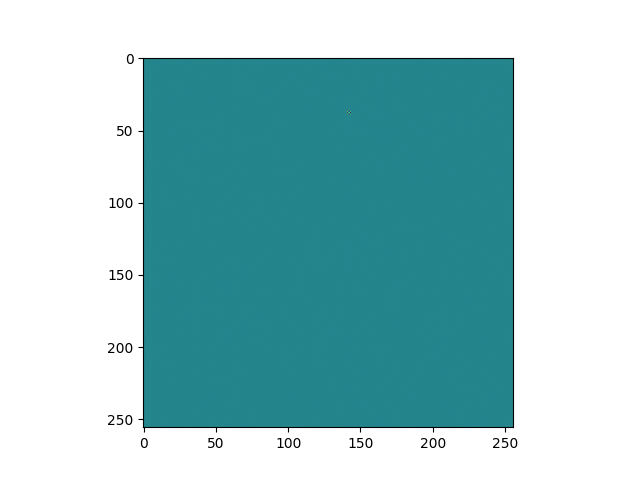

In [5]:
figure()
imshow(gold.real)

<IPython.core.display.Javascript object>


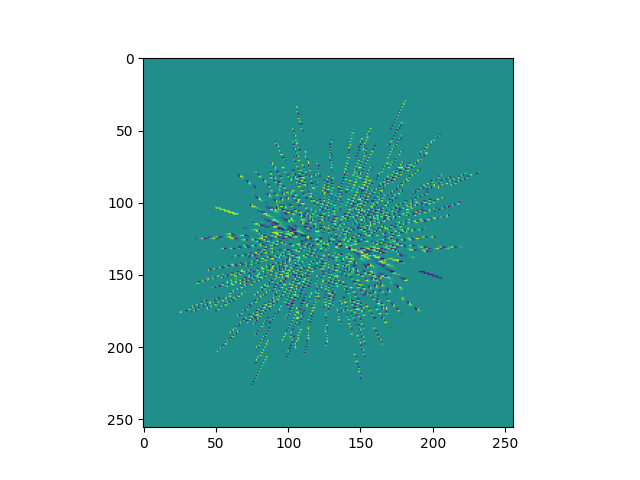

In [6]:
figure()
imshow(np.angle(din))

<IPython.core.display.Javascript object>


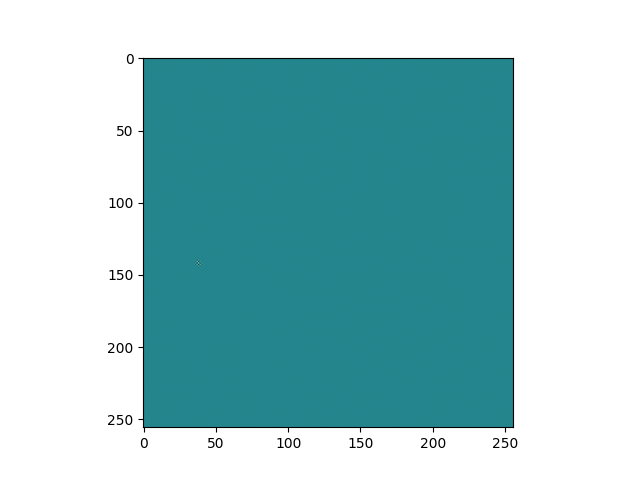

In [7]:
figure()
imshow(np.fft.fft2(din).real)

<IPython.core.display.Javascript object>


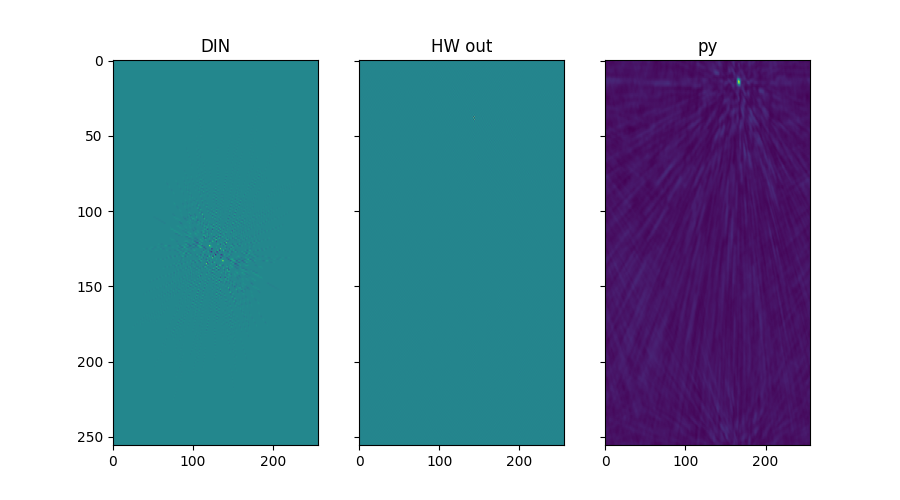

Text(0.5, 1.0, 'py')

In [8]:
fig,ax = subplots(1,3, sharex=True, sharey=True)
fig.set_size_inches((9,5))
ax[0].imshow(din.real, aspect='auto')
ax[1].imshow(gold.real, aspect='auto')
x = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(din)).real)
#x = np.fft.fft2(din.T).real
ax[2].imshow(x, aspect='auto')
ax[0].set_title('DIN')
ax[1].set_title('HW out')
ax[2].set_title('py')

In [9]:
NPIX = 256
NFFT = 16
xclbin = 'kernel_ABC.hw.xilinx_u280_xdma_201920_3.xclbin'

class GenericCu(Kernel):
    def __init__(self, name, device, xbin, icu):
        super().__init__(device, xbin, f'{name}:{name}_{icu+1}')
        
if False: # Driving FFT with pyxrt hangs
    device = pyxrt.device(0)
    xbin = pyxrt.xclbin(xclbin)
    uuid = device.load_xclbin(xbin)
    iplist = xbin.get_ips()
    for ip in iplist:
        print(ip.get_name())
        
    in_r = Buffer((NFFT, NPIX, NPIX), np.int16, device, kernela.krnl.group_id(0)).clear()
    in_i = Buffer((NFFT, NPIX, NPIX), np.int16, device, kernela.krnl.group_id(1)).clear()
    out_r = Buffer((NFFT, NPIX, NPIX), np.int16, device, kernelc.krnl.group_id(1)).clear()
    out_i = Buffer((NFFT, NPIX, NPIX), np.int16, device, kernelc.krnl.group_id(2)).clear()
    
    fftcu = GenericCu('fft2d', device, xbin, 0)
    kernela = GenericCu('kernel_A', device, xbin, 0)
    kernelc = GenericCu('kernel_C', device, xbin, 0)
               

In [10]:
def runfft(inbuf, scale1=0, scale2=7):
    in_r.nparr[:] = inbuf.real
    in_i.nparr[:] = inbuf.imag
    in_r.copy_to_device()
    in_i.copy_to_device()
    no512b = 256*256*32//512
    print('Copied')
    
    outd = np.zeros_like(inbuf)
    fft_cfg = make_fft_config(NFFT, scale1, scale2)
    fft_cfg = 1049024
    # run FFT and kernel a b c
    print('no512b', no512b, type(no512b), 'NFFT', NFFT, type(NFFT))
    r1 = kernelc(out_r, out_i, no512b, NFFT)
    time.sleep(0.1)
    r2 = fftcu(fft_cfg, fft_cfg)
    time.sleep(0.1)
    r3 = kernela(in_r, in_i, no512b, NFFT)
    print('Launched')
    
    return (r1, r2, r3)
    
    sleep = 0.0
    if sleep != 0:
        time.sleep(sleep)
    else:
        r1.wait(0)
        print('r1')
        r2.wait(0)
        print('r2')
        r3.wait(0)
        print('r3')
    #unsigned char shift_1st = 0;
    #unsigned char shift_2nd = 7;
    #//unsigned char shift_2nd = scale;
    #unsigned fft_cfg = 0;
    #fft_cfg = ntimes << 16 | shift_2nd<<6 | shift_1st<<3;
    #//cout << endl << "scale for second stage = " << (int) shift_2nd << endl;

    
    out_r.copy_from_device()
    out_i.copy_from_device()
    outd.real = out_r.nparr[:]
    outd.imag = out_i.nparr[:]

    return outd
    

In [11]:
import subprocess
def runfft2(din):
    assert np.all(abs(din.real) < 1<<16 - 1)
    assert np.all(abs(din.imag) < 1<<16 - 1)
    din.real.astype(np.int16).tofile('din16b_r.bin')
    din.imag.astype(np.int16).tofile('din16b_i.bin')
    cmd = f'./runfft {xclbin} {NFFT}'
    subprocess.check_call(cmd, shell=True)
    out0 = np.fromfile('out0.bin', dtype=np.int16)
    out1 = np.fromfile('out1.bin', dtype=np.int16)
    out = np.zeros(out0.shape, dtype=np.complex64)
    out.real = out0
    out.imag = out1
    out = out.reshape(NPIX, NPIX)
    return out
    

    

In [12]:
din = np.zeros((NFFT, NPIX, NPIX), dtype=np.complex64)
din = loaddata('origdata/din16b')

#din.real[0,0,0] =  1024
scale=16
dout = np.fft.fftshift(runfft2(np.fft.fftshift(din).T*scale))
doutpy = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(din)))
fig, ax = subplots(2,3, sharex=True, sharey=True)
scale=doutpy.real.max() / dout.real.max()
diff = dout - doutpy/scale

print(f'{din.shape} dout {dout.real.max()} doutpy {doutpy.real.max()} scale {scale} diffrms={diff.real.std()} diffmax={diff.real.max()}')

ax = ax.flatten()
ax[0].imshow(dout.real)
ax[1].imshow(doutpy.real)
ax[2].imshow(diff.real)

ax[3].imshow(dout.imag)
ax[4].imshow(doutpy.imag)
ax[5].imshow(diff.imag)

ax[0].set_title('HW')
ax[1].set_title('py')
ax[2].set_title('diff')
scale


CalledProcessError: Command './runfft kernel_ABC.hw.xilinx_u280_xdma_201920_3.xclbin 16' returned non-zero exit status 1.

In [ ]:
scale

In [ ]:
diff.std()

In [ ]:
diff.real.std()

In [ ]:
np.abs(diff).std()

In [ ]:
diff.imag.std()

In [ ]:
np.sqrt(diff.imag.std()**2 + diff.real.std()**2) - diff.std()

In [ ]:
din = np.zeros((NPIX, NPIX), dtype=np.complex64)

#din.real[128,128+5] = 64*16

din.real[128+6,128+0] = 64*16

scale=16
dout = np.fft.fftshift(runfft2(np.fft.fftshift(din.T)*scale))
doutpy = np.fft.fftshift(np.fft.fft2(np.fft.fftshift(din)))
fig, ax = subplots(2,3, sharex=True, sharey=True)
scale=doutpy.real.max() / dout.real.max()
diff = dout - doutpy/scale

print(f'dout {dout.real.max()} doutpy {doutpy.real.max()} scale {scale} diffrms={diff.std()} diffmax={diff.max()}')

ax = ax.flatten()
ax[0].imshow(dout.real)
ax[1].imshow(doutpy.real)
ax[2].imshow(diff.real)

ax[3].imshow(dout.imag)
ax[4].imshow(doutpy.imag)
ax[5].imshow(diff.imag)

ax[0].set_title('HW')
ax[1].set_title('py')
ax[2].set_title('diff')
scale